# PEM Electrolyzer Model and Optimal PWL Approximation

This notebook implements the complete workflow used for the PEM electrolyzer:

1. Nonlinear PEM electrochemical model.
2. Capacity-normalized hydrogen-production function
   \[
   h(x)=\frac{\dot m_{H_2}(x)}{P_{\mathrm{EL}}^{\max}},\qquad x=\frac{P_{\mathrm{EL}}}{P_{\mathrm{EL}}^{\max}}.
   \]
3. Exactly 1000 uniformly spaced candidate points over the productive domain \(x\in[0.15,1]\).
4. Candidate-segment SSE based on endpoint-interpolating chords.
5. Dynamic programming for globally optimal breakpoint selection within the 1000-point partition.
6. Recovery of the PWL coefficients \(A_n\) and \(B_n\), where
   \[
   h(x)\approx A_nx+B_n,
   \]
   implying
   \[
   \dot m_{H_2}\approx A_nP_{\mathrm{EL}}+B_nP_{\mathrm{EL}}^{\max}.
   \]


In [25]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Fundamental constants and reference data

In [26]:

# ============================================================
# FUNDAMENTAL CONSTANTS
# ============================================================
R = 8.314
F_const = 96485.0
M_H2 = 2.01588e-3

# ============================================================
# OPERATING CONDITIONS
# ============================================================
T_cell = 60.0
T_std = 298.15
p_cat = 30.0
p_an = 30.0
i_max = 2.0e4
i_lim = 3.0e5

# ============================================================
# PEM STACK REFERENCE DATA
# ============================================================
C_E = 94.7
A_cell = 0.2
V_rated_reference = 2.04
H2_rated_reference = 1765.0

# ============================================================
# ECONOMIC / SYSTEM DATA
# ============================================================
CAPEX_PEM = 1200.0
MR_PEM = 0.04
stack_lifetime = 10
BOP_lifetime = 25
replacement_cost = 0.27
SEC_stack_reference = 55.7
SEC_BOP_reference = 4.0


## 2. Electrochemical parameters

In [27]:

# Activation
alpha_cat = 0.302
alpha_an = 0.676
i0_ref_cat = 52.0
i0_ref_an = 3.0e-4
E_act_cat = 8.96e3
E_act_an = 60.0e3

# Catalyst
phi_I_cat = 0.75
phi_I_an = 0.75
m_M_cat = 0.3e-2
m_M_an = 1.0e-2
rho_M_cat = 21.45e3
rho_M_an = 22.65e3
d_M_cat = 2.7e-9
d_M_an = 2.9e-9

# Membrane / ohmic
sigma_mem_ref = 100.9
E_act_mem = 9.91e3
delta_mem = 1.83e-4
ASR_elec_cm2 = 0.1048
ASR_elec = ASR_elec_cm2 * 1e-4

# Faraday efficiency
# eta_F = a_F * i**b_F + c_F
# i is interpreted as current density [A/m²] in this implementation.
a_F = -0.1037
b_F = -1.0
c_F = 1.0


### Modeling note
The effective electrical ASR is treated as a calibrated parameter used to reproduce the reported PEM rated polarization point. The Faradaic-efficiency correlation is retained as adopted in the current PEM implementation. These assumptions should be stated explicitly when the model is documented in the congress paper.

## 3. Cell-voltage model

In [28]:

def p_H2O(T_C):
    return (610.0 / 1e5) * np.exp(17.2694 * T_C / (T_C + 238.3))


def E0(T_K):
    return 1.229 - 0.9e-3 * (T_K - T_std)


def V_rev(T_C, p_cat, p_an):
    T_K = T_C + 273.15
    p_water = p_H2O(T_C)
    return (
        E0(T_K)
        + R * T_K / (2.0 * F_const)
        * np.log(((p_cat - p_water) * np.sqrt(p_an - p_water)) / p_water)
    )


def gamma_M(phi_I, m_M, rho_M, d_M):
    return phi_I * m_M * 6.0 / (rho_M * d_M)


gamma_cat = gamma_M(phi_I_cat, m_M_cat, rho_M_cat, d_M_cat)
gamma_an = gamma_M(phi_I_an, m_M_an, rho_M_an, d_M_an)


def i0_exchange(T_K, gamma, i0_ref, E_act):
    return gamma * i0_ref * np.exp(-(E_act / R) * (1.0 / T_K - 1.0 / T_std))


def theta_bubble(T_K, i):
    return (
        -97.25
        + 182.0 * (T_K / T_std)
        - 84.0 * (T_K / T_std)**2
    ) * (i / i_lim)**0.3


def V_act(T_C, i):
    T_K = T_C + 273.15
    theta = theta_bubble(T_K, i)
    i0_cat = i0_exchange(T_K, gamma_cat, i0_ref_cat, E_act_cat)
    i0_an = i0_exchange(T_K, gamma_an, i0_ref_an, E_act_an)

    V_act_cat = (R * T_K / (alpha_cat * F_const)) * np.arcsinh(
        i / (2.0 * i0_cat * (1.0 - theta))
    )
    V_act_an = (R * T_K / (alpha_an * F_const)) * np.arcsinh(
        i / (2.0 * i0_an * (1.0 - theta))
    )
    return V_act_cat + V_act_an


def sigma_mem(T_K):
    return sigma_mem_ref * np.exp(-(E_act_mem / R) * (1.0 / T_K - 1.0 / T_std))


def ASR_mem(T_K):
    return delta_mem / sigma_mem(T_K)


def ASR_eq(T_K):
    return ASR_elec + ASR_mem(T_K)


def V_ohm(T_C, i):
    T_K = T_C + 273.15
    return ASR_eq(T_K) * i


def V_diff(T_C, i):
    T_K = T_C + 273.15
    return (R * T_K / (4.0 * F_const)) * np.log(1.0 - i / i_lim)


def V_cell(T_C, p_cat, p_an, i):
    return (
        V_rev(T_C, p_cat, p_an)
        + V_act(T_C, i)
        + V_ohm(T_C, i)
        + V_diff(T_C, i)
    )


## 4. Faraday efficiency, stack scaling, hydrogen production and power

In [29]:

def eta_F(i):
    return a_F * i**b_F + c_F


def n_cell(i_max, A_cell, C_E, T_C, p_cat, p_an):
    I_max_cell = i_max * A_cell
    V_max_cell = V_cell(T_C, p_cat, p_an, i_max)
    P_max_cell = I_max_cell * V_max_cell
    return C_E * 1e6 / P_max_cell


def H2_production(i, A_cell, n_c):
    n_H2_mol_s = eta_F(i) * n_c * i * A_cell / (2.0 * F_const)
    return n_H2_mol_s * M_H2 * 3600.0


def stack_power(T_C, p_cat, p_an, i, A_cell, n_c):
    return V_cell(T_C, p_cat, p_an, i) * i * A_cell * n_c / 1e6


def eta_kg_per_MWh(T_C, p_cat, p_an, i, A_cell, n_c):
    P_MW = stack_power(T_C, p_cat, p_an, i, A_cell, n_c)
    H2_kg_h = H2_production(i, A_cell, n_c)
    return H2_kg_h / P_MW


## 5. Evaluate and verify the nonlinear PEM model

In [30]:

n_c = n_cell(i_max, A_cell, C_E, T_cell, p_cat, p_an)
i = np.linspace(1.0, i_max, 500)

V_cell_values = V_cell(T_cell, p_cat, p_an, i)
P_elec = stack_power(T_cell, p_cat, p_an, i, A_cell, n_c)
H2_prod_kg_h = H2_production(i, A_cell, n_c)
eta_F_values = eta_F(i)
efficiency_kg_per_MWh = eta_kg_per_MWh(T_cell, p_cat, p_an, i, A_cell, n_c)

P_base = P_elec[-1]
P_elec_pu = P_elec / P_base

print("======================================================")
print("PEM ELECTROLYZER MODEL")
print("======================================================")
print(f"Temperature                  = {T_cell:.2f} °C")
print(f"Cathode pressure             = {p_cat:.2f} bar")
print(f"Anode pressure               = {p_an:.2f} bar")
print(f"Maximum current density      = {i_max/1e4:.3f} A/cm²")
print(f"Number of cells              = {n_c:.2f}")
print(f"Maximum stack power          = {P_elec[-1]:.4f} MW")
print(f"Rated target power           = {C_E:.4f} MW")
print(f"Cell voltage at rated point  = {V_cell_values[-1]:.4f} V")
print(f"Reference voltage            = {V_rated_reference:.4f} V")
print(f"H2 production at rated point = {H2_prod_kg_h[-1]:.4f} kg/h")
print(f"Reference H2 production      = {H2_rated_reference:.4f} kg/h")
print(f"Faraday efficiency rated     = {eta_F_values[-1]:.6f}")
print(f"Efficiency at rated point    = {efficiency_kg_per_MWh[-1]:.4f} kg/MWh")
print(f"SEC at rated point           = {1000.0 / efficiency_kg_per_MWh[-1]:.4f} kWh/kg")
print("======================================================")

print("\nRated-point voltage components")
print("--------------------------------")
print(f"V_rev  = {V_rev(T_cell, p_cat, p_an):.6f} V")
print(f"V_act  = {V_act(T_cell, i_max):.6f} V")
print(f"V_ohm  = {V_ohm(T_cell, i_max):.6f} V")
print(f"V_diff = {V_diff(T_cell, i_max):.6f} V")
print(f"V_cell = {V_cell(T_cell, p_cat, p_an, i_max):.6f} V")


PEM ELECTROLYZER MODEL
Temperature                  = 60.00 °C
Cathode pressure             = 30.00 bar
Anode pressure               = 30.00 bar
Maximum current density      = 2.000 A/cm²
Number of cells              = 11605.60
Maximum stack power          = 94.7000 MW
Rated target power           = 94.7000 MW
Cell voltage at rated point  = 2.0400 V
Reference voltage            = 2.0400 V
H2 production at rated point = 1745.8330 kg/h
Reference H2 production      = 1765.0000 kg/h
Faraday efficiency rated     = 0.999995
Efficiency at rated point    = 18.4354 kg/MWh
SEC at rated point           = 54.2434 kWh/kg

Rated-point voltage components
--------------------------------
V_rev  = 1.293925 V
V_act  = 0.513101 V
V_ohm  = 0.233433 V
V_diff = -0.000495 V
V_cell = 2.039964 V


## 6. Basic PEM curves

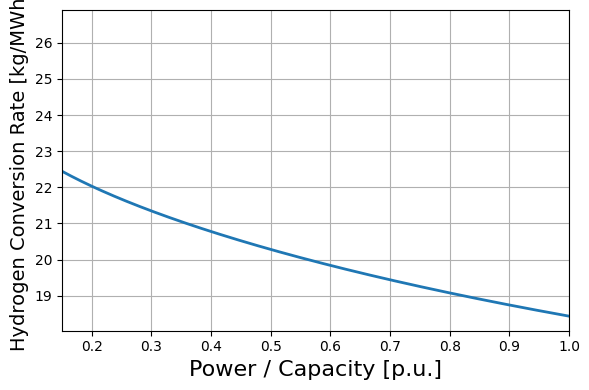

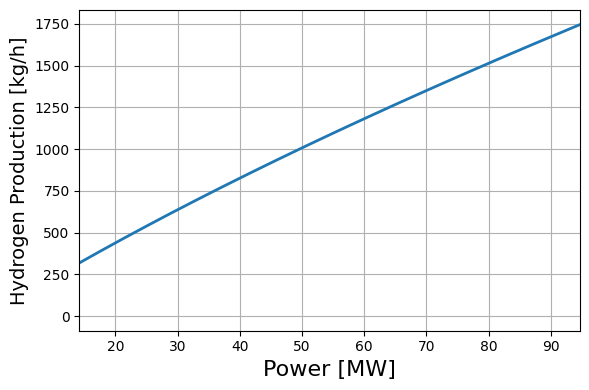

In [31]:

plt.figure(figsize=(6, 4))
plt.plot(P_elec_pu, efficiency_kg_per_MWh, linewidth=2)
plt.xlabel("Power / Capacity [p.u.]", fontsize=16)
plt.ylabel("Hydrogen Conversion Rate [kg/MWh]", fontsize=14)
plt.xlim(0.15, 1.0)
plt.grid()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(P_elec, H2_prod_kg_h, linewidth=2)
plt.xlabel("Power [MW]", fontsize=16)
plt.ylabel("Hydrogen Production [kg/h]", fontsize=14)
plt.xlim(0.15 * P_base, P_base)
plt.grid()
plt.tight_layout()
plt.show()


# PWL approximation

The function used for PWL approximation is

\[
h(x)=\frac{\dot m_{H_2}(x)}{P_{\mathrm{EL}}^{\max}}=x\,\eta_{\mathrm{EL}}(x).
\]

It retains units of kg/MWh and is therefore more precisely a **capacity-normalized hydrogen-production function** rather than a dimensionless normalization.

## 7. Construct the nonlinear PEM production function

In [32]:

x_min = 0.15
x_max = 1.00

# Dense grid only for inversion of the current-density -> power relation.
N_dense = 50000
i_dense = np.linspace(1.0, i_max, N_dense)

P_dense = stack_power(T_cell, p_cat, p_an, i_dense, A_cell, n_c)
H2_dense = H2_production(i_dense, A_cell, n_c)

P_max_model = stack_power(T_cell, p_cat, p_an, i_max, A_cell, n_c)
H2_max_model = H2_production(i_max, A_cell, n_c)

x_dense = P_dense / P_max_model

if not np.all(np.diff(x_dense) > 0):
    raise ValueError("Normalized PEM power is not strictly increasing with current density.")


def h_PEM(x):
    """Capacity-normalized PEM hydrogen production h(x) [kg/MWh]."""
    x = np.asarray(x, dtype=float)

    if np.any(x < x_min) or np.any(x > x_max):
        raise ValueError(f"x must lie inside [{x_min}, {x_max}] p.u.")

    i_x = np.interp(x, x_dense, i_dense)
    H2_x = H2_production(i_x, A_cell, n_c)
    return H2_x / P_max_model


## 8. Create exactly 1000 candidate points

In [33]:

N_points = 1000

# Uniform candidate grid in normalized power.
x_master = np.linspace(x_min, x_max, N_points)
h_master = h_PEM(x_master)

P_master = x_master * P_max_model
H2_master = P_max_model * h_master
efficiency_master = H2_master / P_master
H2_master_pu = H2_master / H2_max_model

# Exact identity check: h(x) = x * eta(x)
h_check = x_master * efficiency_master
max_consistency_error = np.max(np.abs(h_master - h_check))

print("======================================================")
print("PEM MASTER CURVE")
print("======================================================")
print(f"Number of points             = {len(x_master)}")
print(f"Productive domain            = [{x_master[0]:.5f}, {x_master[-1]:.5f}] p.u.")
print(f"Rated PEM power              = {P_max_model:.6f} MW")
print(f"Rated H2 production          = {H2_max_model:.6f} kg/h")
print(f"h(0.15)                      = {h_master[0]:.6f} kg/MWh")
print(f"h(1.00)                      = {h_master[-1]:.6f} kg/MWh")
print(f"Efficiency at 0.15 p.u.      = {efficiency_master[0]:.6f} kg/MWh")
print(f"Efficiency at 1.00 p.u.      = {efficiency_master[-1]:.6f} kg/MWh")
print(f"Consistency error h=x*eta    = {max_consistency_error:.3e}")
print("======================================================")


PEM MASTER CURVE
Number of points             = 1000
Productive domain            = [0.15000, 1.00000] p.u.
Rated PEM power              = 94.700000 MW
Rated H2 production          = 1745.832963 kg/h
h(0.15)                      = 3.366678 kg/MWh
h(1.00)                      = 18.435406 kg/MWh
Efficiency at 0.15 p.u.      = 22.444523 kg/MWh
Efficiency at 1.00 p.u.      = 18.435406 kg/MWh
Consistency error h=x*eta    = 3.553e-15


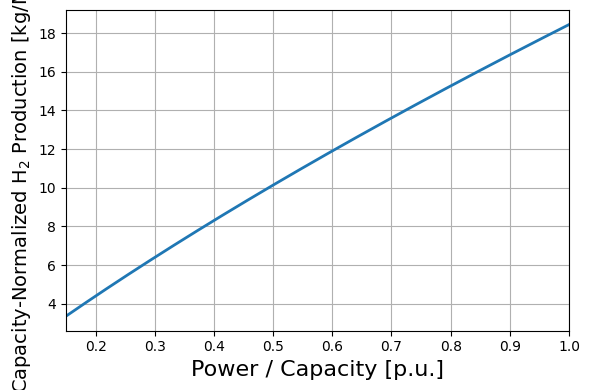

In [34]:

plt.figure(figsize=(6, 4))
plt.plot(x_master, h_master, linewidth=2)
plt.xlabel("Power / Capacity [p.u.]", fontsize=16)
plt.ylabel("Capacity-Normalized H$_2$ Production [kg/MWh]", fontsize=14)
plt.xlim(x_min, x_max)
plt.grid()
plt.tight_layout()
plt.show()


## 9. Candidate chord error matrix

For every candidate pair \(i<j\), the segment is the chord connecting \((x_i,h_i)\) and \((x_j,h_j)\). Its error is

\[
E_{ij}=\sum_{k=i}^{j}\left[h_k-\hat h_{ij}(x_k)\right]^2.
\]

This matches the actual endpoint-interpolating PWL segment used after breakpoint selection.

In [35]:

def build_chord_error_matrix(x, h):
    """Return SSE for every possible endpoint-interpolating candidate chord."""
    x = np.asarray(x, dtype=float)
    h = np.asarray(h, dtype=float)
    n = len(x)

    prefix_x = np.concatenate(([0.0], np.cumsum(x)))
    prefix_x2 = np.concatenate(([0.0], np.cumsum(x**2)))
    prefix_h = np.concatenate(([0.0], np.cumsum(h)))
    prefix_h2 = np.concatenate(([0.0], np.cumsum(h**2)))
    prefix_xh = np.concatenate(([0.0], np.cumsum(x * h)))

    error_matrix = np.full((n, n), np.inf)

    for i in range(n - 1):
        j = np.arange(i + 1, n)

        A = (h[j] - h[i]) / (x[j] - x[i])
        B = h[i] - A * x[i]
        N = (j - i + 1).astype(float)

        sum_x = prefix_x[j + 1] - prefix_x[i]
        sum_x2 = prefix_x2[j + 1] - prefix_x2[i]
        sum_h = prefix_h[j + 1] - prefix_h[i]
        sum_h2 = prefix_h2[j + 1] - prefix_h2[i]
        sum_xh = prefix_xh[j + 1] - prefix_xh[i]

        SSE = (
            sum_h2
            + A**2 * sum_x2
            + B**2 * N
            - 2.0 * A * sum_xh
            - 2.0 * B * sum_h
            + 2.0 * A * B * sum_x
        )

        error_matrix[i, j] = np.maximum(SSE, 0.0)

    return error_matrix


print("Building candidate-segment error matrix...")
error_matrix = build_chord_error_matrix(x_master, h_master)
print("Error matrix completed.")


Building candidate-segment error matrix...
Error matrix completed.


## 10. Dynamic programming

In [36]:

def dynamic_programming_PWL(x, h, error_matrix, segment_list):
    """
    Select globally optimal breakpoint subsets within the supplied master grid.

    Objective: minimize total SSE over all 1000 master points.
    """
    x = np.asarray(x, dtype=float)
    h = np.asarray(h, dtype=float)

    n = len(x)
    max_segments = max(segment_list)

    # cost[k,j] = minimum SSE for points 0,...,j using k segments.
    cost = np.full((max_segments + 1, n), np.inf)
    prev = np.full((max_segments + 1, n), -1, dtype=int)

    # Base case: one segment from point 0 to j.
    cost[1, 1:] = error_matrix[0, 1:]

    for k in range(2, max_segments + 1):
        for j in range(k, n):
            i_candidates = np.arange(k - 1, j)
            candidate_costs = cost[k - 1, i_candidates] + error_matrix[i_candidates, j]

            best_position = np.argmin(candidate_costs)
            best_i = i_candidates[best_position]

            cost[k, j] = candidate_costs[best_position]
            prev[k, j] = best_i

    results = {}

    for num_segments in segment_list:
        j = n - 1
        breakpoint_indices = [j]

        for k in range(num_segments, 1, -1):
            j = prev[k, j]
            if j < 0:
                raise RuntimeError("Dynamic-programming backtracking failed.")
            breakpoint_indices.append(j)

        breakpoint_indices.append(0)
        breakpoint_indices = np.array(sorted(breakpoint_indices), dtype=int)

        x_breakpoints = x[breakpoint_indices]
        h_breakpoints = h[breakpoint_indices]

        A_segments = []
        B_segments = []

        for s in range(num_segments):
            x0, x1 = x_breakpoints[s], x_breakpoints[s + 1]
            h0, h1 = h_breakpoints[s], h_breakpoints[s + 1]

            A = (h1 - h0) / (x1 - x0)
            B = h0 - A * x0

            A_segments.append(A)
            B_segments.append(B)

        results[num_segments] = {
            "breakpoint_indices": breakpoint_indices,
            "x_breakpoints": x_breakpoints,
            "h_breakpoints": h_breakpoints,
            "A": np.asarray(A_segments),
            "B": np.asarray(B_segments),
            "SSE": cost[num_segments, n - 1],
        }

    return results


## 11. Evaluate a PWL solution

In [37]:

def evaluate_PWL(x, x_breakpoints, A_segments, B_segments):
    """Evaluate the continuous PWL function on the productive domain."""
    x = np.asarray(x, dtype=float)

    segment_index = np.searchsorted(
        x_breakpoints[1:-1],
        x,
        side="right"
    )

    return A_segments[segment_index] * x + B_segments[segment_index]


## 12. Solve alternative segmentation levels

In [38]:

segment_list = [3, 5, 6, 9, 12, 15]

DP_results = dynamic_programming_PWL(
    x_master,
    h_master,
    error_matrix,
    segment_list
)

print("Dynamic-programming optimization completed.")


Dynamic-programming optimization completed.


## 13. Approximation metrics and optimal breakpoints

In [39]:

print("======================================================")
print("PEM PWL DYNAMIC-PROGRAMMING RESULTS")
print("======================================================")

for num_segments in segment_list:
    result = DP_results[num_segments]

    h_approx = evaluate_PWL(
        x_master,
        result["x_breakpoints"],
        result["A"],
        result["B"]
    )

    error = h_master - h_approx

    SSE = np.sum(error**2)
    RMSE = np.sqrt(np.mean(error**2))
    MAE = np.mean(np.abs(error))
    max_abs_error = np.max(np.abs(error))

    RMSE_percent = 100.0 * RMSE / h_master[-1]
    max_error_percent = 100.0 * max_abs_error / h_master[-1]

    result["RMSE"] = RMSE
    result["MAE"] = MAE
    result["max_abs_error"] = max_abs_error
    result["RMSE_percent"] = RMSE_percent
    result["max_error_percent"] = max_error_percent

    print()
    print(f"{num_segments} SEGMENTS")
    print("----------------------------------------------")
    print("Breakpoints:")
    print("[" + ", ".join(f"{value:.5f}" for value in result["x_breakpoints"]) + "]")
    print(f"SSE                     = {SSE:.10e}")
    print(f"RMSE                    = {RMSE:.10e} kg/MWh")
    print(f"RMSE / rated h          = {RMSE_percent:.6f} %")
    print(f"Maximum absolute error  = {max_abs_error:.10e} kg/MWh")
    print(f"Maximum error / rated h = {max_error_percent:.6f} %")

print("======================================================")


PEM PWL DYNAMIC-PROGRAMMING RESULTS

3 SEGMENTS
----------------------------------------------
Breakpoints:
[0.15000, 0.38994, 0.67327, 1.00000]
SSE                     = 2.1841244593e+00
RMSE                    = 4.6734617355e-02 kg/MWh
RMSE / rated h          = 0.253505 %
Maximum absolute error  = 6.9638939665e-02 kg/MWh
Maximum error / rated h = 0.377746 %

5 SEGMENTS
----------------------------------------------
Breakpoints:
[0.15000, 0.28869, 0.44354, 0.61286, 0.79835, 1.00000]
SSE                     = 2.8363010982e-01
RMSE                    = 1.6841321499e-02 kg/MWh
RMSE / rated h          = 0.091353 %
Maximum absolute error  = 2.5687838915e-02 kg/MWh
Maximum error / rated h = 0.139340 %

6 SEGMENTS
----------------------------------------------
Breakpoints:
[0.15000, 0.26401, 0.38909, 0.52523, 0.67242, 0.83068, 1.00000]
SSE                     = 1.3683263569e-01
RMSE                    = 1.1697548277e-02 kg/MWh
RMSE / rated h          = 0.063452 %
Maximum absolute error  = 1.

## 14. Error reduction versus number of segments

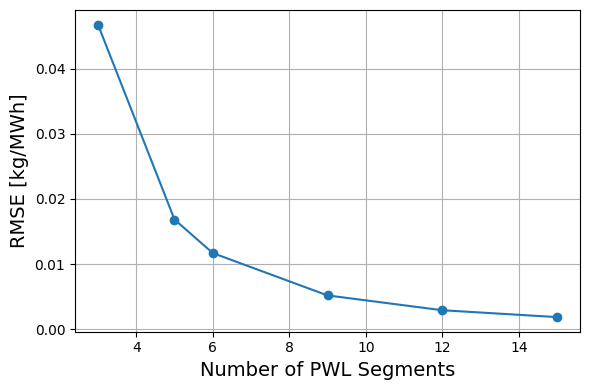

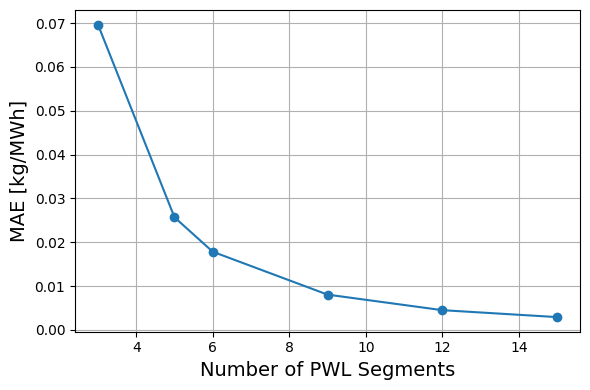

In [40]:

segment_counts = np.array(segment_list)
rmse_values = np.array([DP_results[s]["RMSE"] for s in segment_list])
max_error_values = np.array([DP_results[s]["max_abs_error"] for s in segment_list])

plt.figure(figsize=(6, 4))
plt.plot(segment_counts, rmse_values, marker="o")
plt.xlabel("Number of PWL Segments", fontsize=14)
plt.ylabel("RMSE [kg/MWh]", fontsize=14)
plt.grid()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(segment_counts, max_error_values, marker="o")
plt.xlabel("Number of PWL Segments", fontsize=14)
plt.ylabel("MAE [kg/MWh]", fontsize=14)
plt.grid()
plt.tight_layout()
plt.show()


## 15. Select one PWL model and print coefficients

In [41]:

selected_segments = 9
result = DP_results[selected_segments]

x_breakpoints = result["x_breakpoints"]
h_breakpoints = result["h_breakpoints"]
A_segments = result["A"]
B_segments = result["B"]

print("======================================================")
print(f"PEM PWL MODEL: {selected_segments} SEGMENTS")
print("======================================================")

for n in range(selected_segments):
    print(
        f"Segment {n+1:2d}: "
        f"[{x_breakpoints[n]:.5f}, {x_breakpoints[n+1]:.5f}]  "
        f"A = {A_segments[n]:.8f}  "
        f"B = {B_segments[n]:.8f}"
    )

print("======================================================")


PEM PWL MODEL: 9 SEGMENTS
Segment  1: [0.15000, 0.22487]  A = 20.64236386  B = 0.27032387
Segment  2: [0.22487, 0.30485]  A = 19.82820576  B = 0.45340757
Segment  3: [0.30485, 0.38994]  A = 19.08831142  B = 0.67896795
Segment  4: [0.38994, 0.47928]  A = 18.40903745  B = 0.94384400
Segment  5: [0.47928, 0.57372]  A = 17.78170873  B = 1.24450966
Segment  6: [0.57372, 0.67327]  A = 17.19837889  B = 1.57917982
Segment  7: [0.67327, 0.77708]  A = 16.65761691  B = 1.94326041
Segment  8: [0.77708, 0.88599]  A = 16.15539358  B = 2.33352665
Segment  9: [0.88599, 1.00000]  A = 15.68602959  B = 2.74937657


## 16. Plot the selected PWL approximation

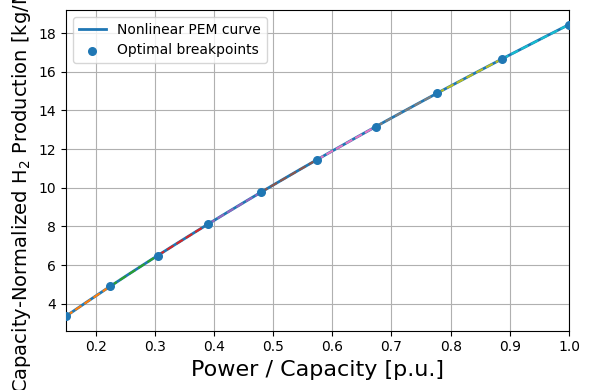

In [42]:

plt.figure(figsize=(6, 4))

plt.plot(
    x_master,
    h_master,
    linewidth=2,
    label="Nonlinear PEM curve"
)

for n in range(selected_segments):
    x_seg = np.linspace(x_breakpoints[n], x_breakpoints[n + 1], 100)
    h_seg = A_segments[n] * x_seg + B_segments[n]
    plt.plot(x_seg, h_seg, linestyle="--", linewidth=1.5)

plt.scatter(
    x_breakpoints,
    h_breakpoints,
    s=30,
    zorder=3,
    label="Optimal breakpoints"
)

plt.xlabel("Power / Capacity [p.u.]", fontsize=16)
plt.ylabel("Capacity-Normalized H$_2$ Production [kg/MWh]", fontsize=14)
plt.xlim(x_min, x_max)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()


## 17. Implied hydrogen-conversion-rate approximation

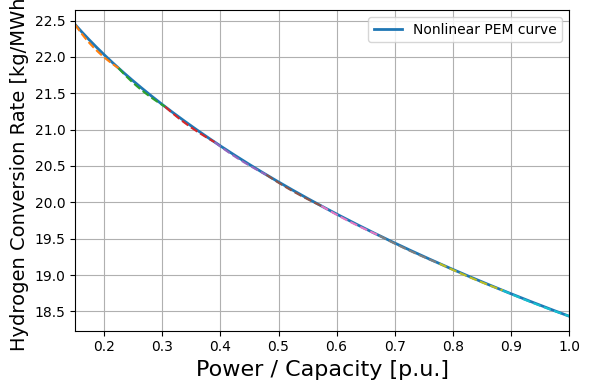

In [43]:

plt.figure(figsize=(6, 4))

plt.plot(
    x_master,
    efficiency_master,
    linewidth=2,
    label="Nonlinear PEM curve"
)

for n in range(selected_segments):
    x_seg = np.linspace(x_breakpoints[n], x_breakpoints[n + 1], 100)
    efficiency_seg = A_segments[n] + B_segments[n] / x_seg
    plt.plot(x_seg, efficiency_seg, linestyle="--", linewidth=1.5)

plt.xlabel("Power / Capacity [p.u.]", fontsize=16)
plt.ylabel("Hydrogen Conversion Rate [kg/MWh]", fontsize=14)
plt.xlim(x_min, x_max)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()


## 18. Optimization-ready form

For segment \(n\),

\[
h(x)=A_nx+B_n,\qquad x=\frac{P_{\mathrm{EL}}}{P_{\mathrm{EL}}^{\max}}.
\]

Hence,

\[
\dot m_{H_2}
=P_{\mathrm{EL}}^{\max}h(x)
\approx
A_nP_{\mathrm{EL}}+B_nP_{\mathrm{EL}}^{\max}.
\]

The arrays `x_breakpoints`, `A_segments`, and `B_segments` are therefore the quantities required for the later MILP/PWL ammonia-operation model.

In [ ]:
# ============================================================
# FINAL CHECK: PWL UNDERESTIMATION
# ============================================================

h_PWL = evaluate_PWL(
    x_master,
    x_breakpoints,
    A_segments,
    B_segments
)

difference = h_master - h_PWL

print("======================================================")
print("PWL UNDERESTIMATION CHECK")
print("======================================================")

print(
    f"Minimum nonlinear - PWL difference = "
    f"{np.min(difference):.10e} kg/MWh"
)

print(
    f"Maximum nonlinear - PWL difference = "
    f"{np.max(difference):.10e} kg/MWh"
)

print(
    f"Number of overestimating points    = "
    f"{np.sum(difference < -1e-10)}"
)

print("======================================================")

PWL UNDERESTIMATION CHECK
Minimum nonlinear - PWL difference = 0.0000000000e+00 kg/MWh
Maximum nonlinear - PWL difference = 8.0588432506e-03 kg/MWh
Number of overestimating points    = 0


: 